<h1 style="color:#38BDF8; text-align:center; font-weight:bold; border-bottom:3px solid #38BDF8;">Day 2 — Probability &amp; Distributions</h1>
<h3 style="text-align:center; color:#BE185D;">Core Rules, Conditional Probability, Bayes' Theorem &amp; Common Distributions</h3>


<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">Table of Contents</h2>

<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing NumPy &amp; Matplotlib</a></li>
<li><a href="#section1">1. Probability Basics — The Big Picture</a></li>
<li><a href="#section2">2. Core Rules — Complement, Addition, Multiplication</a></li>
<li><a href="#section3">3. Conditional Probability — P(A | B)</a></li>
<li><a href="#section4">4. Bayes' Theorem</a></li>
<li><a href="#section5">5. Common Distributions — Normal, Binomial, Uniform</a></li>
<li><a href="#section6">6. Common Mistakes to Avoid</a></li>
<li><a href="#section7">7. Quick Reference — Cheat Sheet</a></li>
<li><a href="#section8">8. Hands-On Lab — Probability &amp; Distributions in Code</a></li>
<li><a href="#section9">9. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section10">10. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">0. Setup — Importing NumPy &amp; Matplotlib</h2>

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> Today's toolbox is the same one from Week 1: <b>NumPy</b> to simulate random events and sample from distributions, and <b>Matplotlib</b> to visualize the resulting shapes.
</div>


In [2]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

NumPy version: 2.4.6
Matplotlib version: 3.11.1


<a id="section1"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">1. Probability Basics — The Big Picture</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.1 Why probability matters for ML</h3>

Probability quantifies <b>uncertainty</b> — and ML models fundamentally output probabilities. When a model says <i>"85% likely to churn"</i> or <i>"this email is 97% likely to be spam"</i>, it is speaking the language of probability. Understanding this language is essential to understanding what a model is actually telling you.

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.2 What a probability actually is</h3>

A probability is always a number between <b>0</b> (impossible) and <b>1</b> (certain). When outcomes are equally likely, the probability of an event is:

<div style="border-left:5px solid #FACC15; background-color:#fffbea; padding:10px 15px; margin:10px 0; border-radius:4px; color:#78350f; text-align:center;">
<b>P(event) = (favorable outcomes) / (total possible outcomes)</b>
</div>


In [3]:
# Example: probability of rolling a 4 on a fair six-sided die
favorable_outcomes = 1     # only one face shows a 4
total_outcomes = 6         # six faces total

p_rolling_a_4 = favorable_outcomes / total_outcomes
print("P(rolling a 4):", p_rolling_a_4)

P(rolling a 4): 0.16666666666666666


<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> Probabilities are sometimes written as a percentage (e.g. "16.7% chance") and sometimes as a decimal fraction (e.g. "0.167") — these are exactly the same number, just formatted differently.
</div>

<a id="section2"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">2. Core Rules — Complement, Addition, Multiplication</h2>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;">
<th style="padding:8px; text-align:left;">Rule</th>
<th style="padding:8px; text-align:left;">Statement</th>
<th style="padding:8px; text-align:left;">Meaning</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>Complement</b></td><td style="padding:8px; border-top:1px solid #ccc;"><code>P(not A) = 1 - P(A)</code></td><td style="padding:8px; border-top:1px solid #ccc;">The chance something does NOT happen</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>Addition</b></td><td style="padding:8px; border-top:1px solid #ccc;"><code>P(A or B) = P(A) + P(B) - P(A and B)</code></td><td style="padding:8px; border-top:1px solid #ccc;">The chance of either event</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>Multiplication (independent)</b></td><td style="padding:8px; border-top:1px solid #ccc;"><code>P(A and B) = P(A) × P(B)</code></td><td style="padding:8px; border-top:1px solid #ccc;">Both happen, when unrelated</td></tr>
</table>
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 The Complement Rule</h3>

Since something either happens or doesn't, the probabilities of an event and its opposite must always add up to 1. This is often the <i>easiest</i> way to compute a probability — sometimes it's much simpler to calculate what you <i>don't</i> want, and subtract from 1.


In [4]:
p_rain_tomorrow = 0.3

p_no_rain_tomorrow = 1 - p_rain_tomorrow
print("P(no rain tomorrow):", p_no_rain_tomorrow)

P(no rain tomorrow): 0.7


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.2 The Addition Rule</h3>

Used when you want the probability of <b>either</b> of two events happening. We subtract <code>P(A and B)</code> because otherwise the overlap between the two events would be counted twice.


In [5]:
# Example: drawing a card from a standard 52-card deck
# A = drawing a King (4 kings)
# B = drawing a Heart (13 hearts)
# A and B = drawing the King of Hearts (1 card)

p_king = 4/52
p_heart = 13/52
p_king_and_heart = 1/52

p_king_or_heart = p_king + p_heart - p_king_and_heart
print("P(King or Heart):", round(p_king_or_heart, 4))

P(King or Heart): 0.3077


<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> If the two events can never happen together (called <b>mutually exclusive</b> — e.g. rolling a 2 <i>or</i> a 5 on one die roll), then <code>P(A and B) = 0</code>, and the formula simplifies to just <code>P(A) + P(B)</code>.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.3 The Multiplication Rule (independent events)</h3>

Used when you want the probability of <b>both</b> of two <b>independent</b> events happening — meaning one event's outcome has no effect on the other's.


In [6]:
# Example: flipping a coin twice -- the two flips are independent
p_heads = 0.5

p_heads_twice_in_a_row = p_heads * p_heads
print("P(heads, then heads again):", p_heads_twice_in_a_row)

P(heads, then heads again): 0.25


<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> The multiplication rule above only works for <b>independent</b> events. If the events are <i>not</i> independent (one affects the other), you need <b>conditional probability</b> instead — which is exactly what we cover next.
</div>

<a id="section3"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">3. Conditional Probability — P(A | B)</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.1 What "conditional" means</h3>

<b>Conditional probability</b>, written <code>P(A | B)</code> (read as <i>"the probability of A, given B"</i>), is the probability of event A happening, <b>knowing that event B has already happened</b>. It is the foundation of nearly all predictive modeling: <i>"given these customer features, what is the probability they churn?"</i> is a conditional probability question.

<div style="border-left:5px solid #FACC15; background-color:#fffbea; padding:10px 15px; margin:10px 0; border-radius:4px; color:#78350f; text-align:center;">
<b>P(A | B) = P(A and B) / P(B)</b>
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.2 A worked example</h3>

Imagine a small survey of 100 interns: 40 are in the "AI & ML" track, and among those, 30 also report enjoying Python the most. What is the probability an intern enjoys Python the most, <b>given</b> that they are in the AI & ML track?


In [7]:
total_interns = 100
ai_ml_track = 40                 # P(B): in the AI & ML track
ai_ml_and_likes_python = 30      # P(A and B): in AI & ML AND enjoys Python most

p_b = ai_ml_track / total_interns
p_a_and_b = ai_ml_and_likes_python / total_interns

p_a_given_b = p_a_and_b / p_b
print("P(likes Python | in AI & ML track):", p_a_given_b)

P(likes Python | in AI & ML track): 0.7499999999999999


<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> Notice the result (0.75) is different from the plain, "unconditional" probability of liking Python among <i>all</i> interns — that's exactly the point of conditional probability: it lets new information (being in the AI &amp; ML track) update our estimate.
</div>

<a id="section4"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">4. Bayes' Theorem</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.1 Reversing a conditional probability</h3>

Sometimes you know <code>P(B | A)</code>, but you actually need <code>P(A | B)</code> — the reverse direction. <b>Bayes' theorem</b> is exactly the formula that lets you flip a conditional probability around. It is the mathematical basis of the Naive Bayes classifier, and of updating beliefs as new evidence arrives.

<div style="border-left:5px solid #FACC15; background-color:#fffbea; padding:10px 15px; margin:10px 0; border-radius:4px; color:#78350f; text-align:center;">
<b>P(A | B) = ( P(B | A) × P(A) ) / P(B)</b>
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.2 The intuition: prior, likelihood, posterior</h3>

Bayes' theorem combines what you believed <i>before</i> seeing evidence (the <b>prior</b>, <code>P(A)</code>) with how strongly the evidence supports it (the <b>likelihood</b>, <code>P(B|A)</code>) to produce an updated belief (the <b>posterior</b>, <code>P(A|B)</code>).

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.3 A classic worked example: medical testing</h3>

Imagine a disease that affects <b>1% of the population</b>. A test for it is <b>95% accurate</b> for people who have the disease (it correctly says "positive"), but it also gives a <b>false positive 5% of the time</b> for people who don't have it. If someone tests positive, what is the actual probability they have the disease?


In [8]:
p_disease = 0.01                    # P(A): prior probability of having the disease
p_positive_given_disease = 0.95     # P(B|A): likelihood -- test is 95% accurate if you have it
p_no_disease = 1 - p_disease
p_positive_given_no_disease = 0.05  # false positive rate

# P(B): total probability of testing positive, considering both groups
p_positive = (p_positive_given_disease * p_disease) + (p_positive_given_no_disease * p_no_disease)

# Bayes' theorem: P(A|B) = P(B|A) * P(A) / P(B)
p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print(f"P(testing positive)              : {p_positive:.4f}")
print(f"P(actually having the disease | positive test): {p_disease_given_positive:.4f}")

P(testing positive)              : 0.0590
P(actually having the disease | positive test): 0.1610


<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important — the surprising result:</b> Even with a "95% accurate" test, someone who tests positive only has about a <b>16%</b> chance of actually having the disease! This happens because the disease is so <i>rare</i> (only 1% of the population) that most positive results actually come from the much larger group of healthy people who got a false positive. This is a famous, counter-intuitive result — and it's exactly why Bayes' theorem is so important in real-world decision-making.
</div>

<a id="section5"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">5. Common Distributions — Normal, Binomial, Uniform</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5.1 What a probability distribution is</h3>

A <b>probability distribution</b> describes how likely each possible value of a variable is. Instead of a single probability, a distribution gives you the whole picture — the shape of all the possibilities at once. Three distributions you will meet constantly in ML:


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;">
<th style="padding:8px; text-align:left;">Distribution</th>
<th style="padding:8px; text-align:left;">Describes</th>
<th style="padding:8px; text-align:left;">Example</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>Normal (Gaussian)</b></td><td style="padding:8px; border-top:1px solid #ccc;">Symmetric, bell-shaped data clustered around a mean</td><td style="padding:8px; border-top:1px solid #ccc;">Human heights, measurement error</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>Binomial</b></td><td style="padding:8px; border-top:1px solid #ccc;">Number of successes in a fixed number of yes/no trials</td><td style="padding:8px; border-top:1px solid #ccc;">Number of heads in 10 coin flips</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>Uniform</b></td><td style="padding:8px; border-top:1px solid #ccc;">Every outcome equally likely</td><td style="padding:8px; border-top:1px solid #ccc;">A fair die roll</td></tr>
</table>
</div>

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> The <b>normal distribution</b> matters most: many statistical methods and ML assumptions rely on data being approximately normal, which is one of the first things EDA checks for (coming up on Day 4).
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5.2 The Normal Distribution</h3>

The normal distribution produces the familiar "bell curve" — most values cluster near the mean, and values become rarer the farther they are from it in either direction.


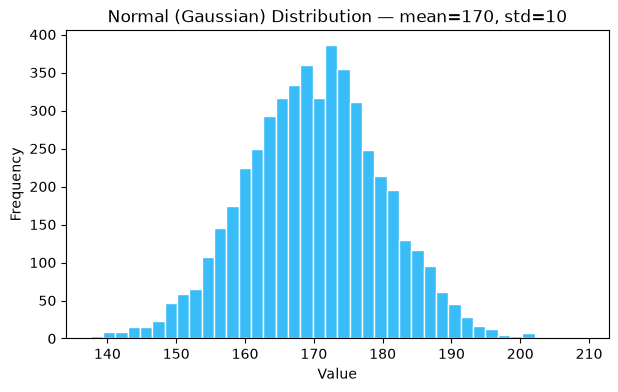

In [9]:
np.random.seed(42)

normal_data = np.random.normal(loc=170, scale=10, size=5000)   # e.g. simulated heights in cm, mean=170, std=10

plt.figure(figsize=(7, 4))
plt.hist(normal_data, bins=40, color="#38BDF8", edgecolor="white")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Normal (Gaussian) Distribution — mean=170, std=10")
plt.show()

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5.3 The Binomial Distribution</h3>

The binomial distribution describes the number of "successes" in a fixed number of independent yes/no trials — like counting how many heads you get across many separate sets of coin flips.


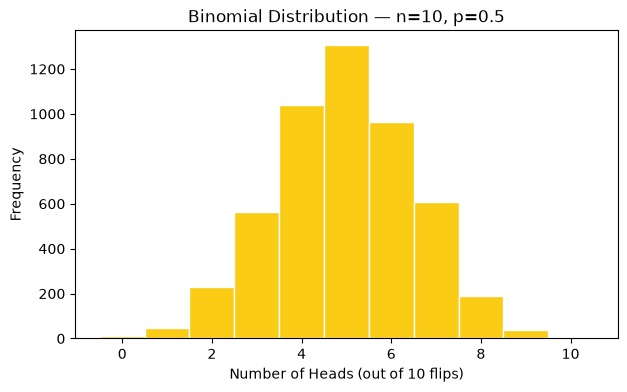

In [10]:
binomial_data = np.random.binomial(n=10, p=0.5, size=5000)   # 10 coin flips, repeated 5000 times

plt.figure(figsize=(7, 4))
plt.hist(binomial_data, bins=range(12), color="#FACC15", edgecolor="white", align="left")
plt.xlabel("Number of Heads (out of 10 flips)")
plt.ylabel("Frequency")
plt.title("Binomial Distribution — n=10, p=0.5")
plt.show()

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5.4 The Uniform Distribution</h3>

The uniform distribution describes a situation where every outcome in a range is equally likely — like rolling a fair die, or generating a random decimal between 0 and 1.


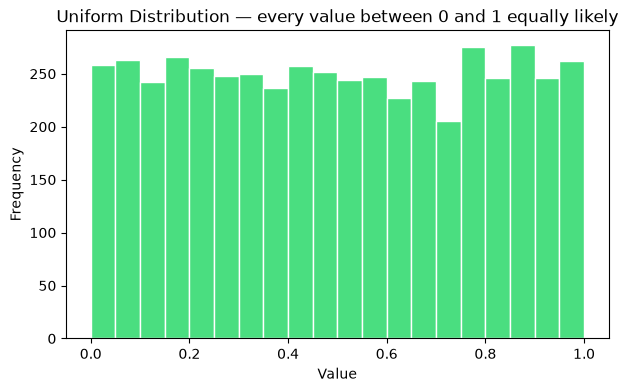

In [11]:
uniform_data = np.random.uniform(low=0, high=1, size=5000)

plt.figure(figsize=(7, 4))
plt.hist(uniform_data, bins=20, color="#4ADE80", edgecolor="white")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Uniform Distribution — every value between 0 and 1 equally likely")
plt.show()

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> Notice the very different shapes: the normal distribution is a smooth bell curve, the binomial distribution is discrete and centered (here, around 5 heads), and the uniform distribution is roughly flat across its whole range. Recognizing these shapes by eye is a skill you'll use constantly during EDA.
</div>

<a id="section6"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">6. Common Mistakes to Avoid</h2>

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b>
<ul>
<li><b>Using the simple multiplication rule for dependent events</b> — <code>P(A) × P(B)</code> only works when A and B are truly <b>independent</b>. If one affects the other, you need conditional probability instead.</li>
<li><b>Forgetting to subtract the overlap in the addition rule</b> — <code>P(A or B) = P(A) + P(B)</code> alone double-counts cases where both happen; always subtract <code>P(A and B)</code> unless the events are mutually exclusive.</li>
<li><b>Confusing P(A | B) with P(B | A)</b> — these are <i>not</i> the same thing! "The probability of rain given clouds" is very different from "the probability of clouds given rain." Mixing these up is one of the most common statistical errors — this exact confusion is why Bayes' theorem exists.</li>
<li><b>Ignoring the base rate (prior)</b> — as the medical testing example showed, a rare condition combined with an imperfect test can produce surprisingly low real-world accuracy, even when the test itself sounds very reliable.</li>
</ul>
</div>


<a id="section7"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">7. Quick Reference — Cheat Sheet</h2>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;">
<th style="padding:8px; text-align:left;">Concept</th>
<th style="padding:8px; text-align:left;">Formula</th>
<th style="padding:8px; text-align:left;">NumPy Equivalent</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Basic probability</td><td style="padding:8px; border-top:1px solid #ccc;"><code>favorable / total</code></td><td style="padding:8px; border-top:1px solid #ccc;">—</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Complement</td><td style="padding:8px; border-top:1px solid #ccc;"><code>P(not A) = 1 - P(A)</code></td><td style="padding:8px; border-top:1px solid #ccc;">—</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Addition</td><td style="padding:8px; border-top:1px solid #ccc;"><code>P(A or B) = P(A)+P(B)-P(A and B)</code></td><td style="padding:8px; border-top:1px solid #ccc;">—</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Multiplication (independent)</td><td style="padding:8px; border-top:1px solid #ccc;"><code>P(A and B) = P(A) × P(B)</code></td><td style="padding:8px; border-top:1px solid #ccc;">—</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Conditional probability</td><td style="padding:8px; border-top:1px solid #ccc;"><code>P(A|B) = P(A and B) / P(B)</code></td><td style="padding:8px; border-top:1px solid #ccc;">—</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Bayes' theorem</td><td style="padding:8px; border-top:1px solid #ccc;"><code>P(A|B) = P(B|A)×P(A) / P(B)</code></td><td style="padding:8px; border-top:1px solid #ccc;">—</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Coin flip simulation</td><td style="padding:8px; border-top:1px solid #ccc;">—</td><td style="padding:8px; border-top:1px solid #ccc;"><code>np.random.choice(["H","T"], size=n)</code></td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Normal distribution</td><td style="padding:8px; border-top:1px solid #ccc;">—</td><td style="padding:8px; border-top:1px solid #ccc;"><code>np.random.normal(loc, scale, size)</code></td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Binomial distribution</td><td style="padding:8px; border-top:1px solid #ccc;">—</td><td style="padding:8px; border-top:1px solid #ccc;"><code>np.random.binomial(n, p, size)</code></td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Uniform distribution</td><td style="padding:8px; border-top:1px solid #ccc;">—</td><td style="padding:8px; border-top:1px solid #ccc;"><code>np.random.uniform(low, high, size)</code></td></tr>
</table>
</div>


<a id="section8"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">8. Hands-On Lab — Probability &amp; Distributions in Code</h2>

<div style="border-left:5px solid #FACC15; background-color:#fffbea; padding:10px 15px; margin:10px 0; border-radius:4px; color:#78350f;">
<b>Goal:</b> Confirm today's theory with simulation — probability theory predicts what <i>should</i> happen on average, and simulation lets us verify it actually does.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Simulate 10,000 coin flips and confirm P(heads) approaches 0.5</h3>
<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> Theory says a fair coin has exactly a 50% chance of heads. Let's flip a simulated coin 10,000 times and see how close we get.
</div>

In [12]:
np.random.seed(42)

flips = np.random.choice(["Heads", "Tails"], size=10000)   # simulate 10,000 fair coin flips

proportion_heads = np.mean(flips == "Heads")
print(f"Proportion of heads out of 10,000 flips: {proportion_heads:.4f}")
print("--> Very close to the theoretical value of 0.5, as expected.")

Proportion of heads out of 10,000 flips: 0.5013
--> Very close to the theoretical value of 0.5, as expected.


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Sample from a normal distribution and plot its histogram</h3>
<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> We'll simulate exam scores that are normally distributed around a mean of 75, with a standard deviation of 8, and confirm the bell shape visually.
</div>

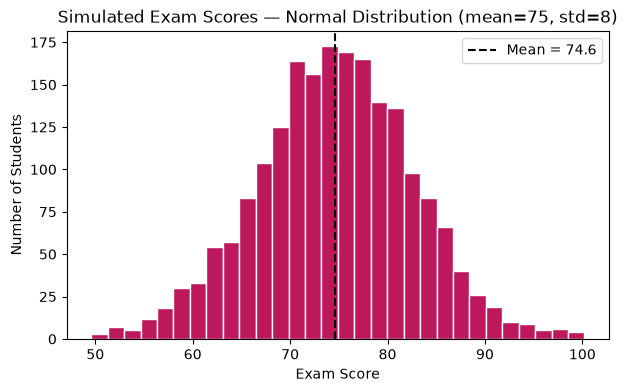

Sample mean: 74.58 (theoretical: 75)
Sample std : 8.04 (theoretical: 8)


In [13]:
exam_scores = np.random.normal(loc=75, scale=8, size=2000)

plt.figure(figsize=(7, 4))
plt.hist(exam_scores, bins=30, color="#BE185D", edgecolor="white")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Simulated Exam Scores — Normal Distribution (mean=75, std=8)")
plt.axvline(exam_scores.mean(), color="black", linestyle="--", label=f"Mean = {exam_scores.mean():.1f}")
plt.legend()
plt.show()

print(f"Sample mean: {exam_scores.mean():.2f} (theoretical: 75)")
print(f"Sample std : {exam_scores.std():.2f} (theoretical: 8)")

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Compute a conditional probability by hand and verify it with simulation</h3>
<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> Scenario: we roll two fair six-sided dice. What is P(the sum is greater than 8 | the first die shows a 5)? We'll compute this by hand, then verify it by simulating thousands of dice rolls.
</div>

In [14]:
# --- By hand ---
# If the first die is 5, the second die must be 4, 5, or 6 for the sum to exceed 8 (5+4=9, 5+5=10, 5+6=11)
# That's 3 favorable outcomes out of 6 possible second-die values
p_by_hand = 3 / 6
print("P(sum > 8 | first die = 5), computed by hand:", p_by_hand)

# --- Verified by simulation ---
np.random.seed(42)
n_rolls = 200_000

die1 = np.random.randint(1, 7, size=n_rolls)   # random integers from 1 to 6
die2 = np.random.randint(1, 7, size=n_rolls)

first_die_is_5 = (die1 == 5)                    # the "given" condition (event B)
sum_greater_than_8 = (die1 + die2) > 8          # the event we care about (event A)

# Conditional probability: among the rolls where B happened, what fraction also had A happen?
p_by_simulation = np.mean(sum_greater_than_8[first_die_is_5])
print("P(sum > 8 | first die = 5), verified by simulation:", round(p_by_simulation, 4))

P(sum > 8 | first die = 5), computed by hand: 0.5
P(sum > 8 | first die = 5), verified by simulation: 0.4975


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Document what each result demonstrates</h3>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Plain-language summary:</b>
<ul>
<li><b>Coin flips:</b> across 10,000 simulated flips, the proportion of heads landed extremely close to the theoretical 0.5 — a direct demonstration that simulated randomness matches probability theory as the sample size grows large (this idea is called the <i>Law of Large Numbers</i>).</li>
<li><b>Normal distribution:</b> the simulated exam scores formed a clear, symmetric bell shape, and the sample mean and standard deviation closely matched the values we asked for (75 and 8) — confirming <code>np.random.normal</code> behaves exactly as the theory predicts.</li>
<li><b>Conditional probability:</b> the hand-calculated value (0.5) and the simulated value from 200,000 dice rolls matched almost exactly — a satisfying confirmation that the conditional probability formula and its real-world frequency interpretation agree.</li>
</ul>
</div>

<a id="section9"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">9. Best Practices &amp; Reproducibility</h2>

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> As always, fix a random seed wherever randomness is used, so your simulations are exactly repeatable by your mentor. We did this at the top of the Hands-On Lab with <code>np.random.seed(42)</code>.
</div>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> A professional checklist for probability problems:
<ul>
<li>Are the events actually <b>independent</b> before using the simple multiplication rule?</li>
<li>Did you check whether you need <code>P(A|B)</code> or <code>P(B|A)</code> — they are not the same?</li>
<li>Whenever the math feels uncertain, try <b>simulating</b> the scenario with NumPy to sanity-check your formula-based answer, exactly like we did in the Hands-On Lab.</li>
</ul>
</div>


<a id="section10"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">10. Summary — What I Learned Today</h2>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b>
<ul>
<li><b>Probability</b> quantifies uncertainty, always a number between 0 and 1 — and it's exactly what ML models output.</li>
<li>The three <b>core rules</b>: <b>complement</b> (1 minus the opposite), <b>addition</b> (either event, minus the double-counted overlap), and <b>multiplication</b> (both events, only valid for <i>independent</i> events).</li>
<li><b>Conditional probability</b> <code>P(A|B)</code> is the probability of A <i>given that</i> B already happened — the foundation of nearly all predictive modeling.</li>
<li><b>Bayes' theorem</b> reverses a conditional probability, combining a <b>prior</b> belief with new <b>evidence</b> to produce an updated <b>posterior</b> belief — and can produce surprising results when an event is rare (as the medical testing example showed).</li>
<li>Three distributions to recognize on sight: <b>normal</b> (bell-shaped, continuous), <b>binomial</b> (counting successes in fixed trials), and <b>uniform</b> (every outcome equally likely).</li>
<li><b>Simulation</b> is a powerful way to sanity-check probability theory — with a large enough sample, simulated results converge to the theoretical prediction.</li>
</ul>
</div>
